# Masterclass 1

So, for me mainly as theoretical physicist this data analysis magic is kinda scary, but I want to challenge me and try to figure this out.

Here:

$$
P_{ee}=1.
$$

The goal is to build the event model

$$
{}^8\mathrm{B}\ \nu_e \rightarrow \nu e\ \mathrm{scattering}\rightarrow e^-_{\rm recoil},
$$

then generate pseudo-data and fit the normalization of the ${}^8\mathrm{B}$ solar-neutrino flux:

$$
\Phi_{^8\mathrm{B}}\rightarrow \alpha_B\Phi_{^8\mathrm{B}}.
$$


## Main outputs

The notebook produces:

1. ${}^8\mathrm{B}$ neutrino spectrum;
2. SK-like recoil-electron spectrum $dN/dT_e$;
3. total expected event count above a chosen threshold;
4. pseudo-data in the same recoil-energy bins;
5. best-fit $\hat\alpha_B$ and a one-dimensional interval from $q(\alpha_B)$.


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["legend.fontsize"] = 11

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. Inputs

As I understand, we have experimental data. In this masterclass it is these three tables:

- `solar_fluxes.csv` — solar-neutrino fluxes;
- `energy_spectra.csv` — normalized energy spectra;
- `nu_electron_recoil_cross_sections.csv` — differential recoil cross sections.


In [60]:
BASE = "https://neutrinohit.github.io/neutrinophysics/solar-neutrino-masterclass"

fluxes = pd.read_csv(f"{BASE}/data/masterclass1/solar_fluxes.csv")
spectra = pd.read_csv(f"{BASE}/data/masterclass1/energy_spectra.csv")
xs = pd.read_csv(f"{BASE}/data/masterclass1/nu_electron_recoil_cross_sections.csv")

print("fluxes columns:", list(fluxes.columns))
print("spectra columns:", list(spectra.columns))
print("cross-section columns:", list(xs.columns))

display(fluxes.head())
display(spectra.head())
display(xs.head())

fluxes columns: ['source', 'flux_cm2_s', 'kind', 'endpoint_MeV', 'line_energies_MeV', 'line_weights', 'group', 'comment']
spectra columns: ['source', 'E_MeV', 'spectrum_per_MeV', 'kind']
cross-section columns: ['E_MeV', 'T_e_MeV', 'T_max_MeV', 'dsigma_nue_cm2_per_MeV', 'dsigma_nux_cm2_per_MeV']


,source,flux_cm2_s,kind,endpoint_MeV,line_energies_MeV,line_weights,group,comment
0,pp,5.980000e+10,continuum,0.42,NaN,NaN,pp-chain,dominant low-energy flux
1,pep,1.440000e+08,line,NaN,1.44,1.0,pp-chain,monoenergetic line
2,hep,7.980000e+03,continuum,18.80,NaN,NaN,pp-chain,rare high-energy tail
3,Be7,4.930000e+09,line,NaN,0.384;0.862,0.103;0.897,pp-chain,electron-capture lines
4,B8,5.460000e+06,continuum,16.00,NaN,NaN,pp-chain,high-energy branch


,source,E_MeV,spectrum_per_MeV,kind
0,pp,0.02,0.147128,continuum
1,pp,0.04,0.531132,continuum
2,pp,0.06,1.072564,continuum
3,pp,0.08,1.700800,continuum
4,pp,0.10,2.354049,continuum


,E_MeV,T_e_MeV,T_max_MeV,dsigma_nue_cm2_per_MeV,dsigma_nux_cm2_per_MeV
0,0.05,0.0,0.008183,1.013464e-44,2.166263e-45
1,0.05,0.1,0.008183,0.000000e+00,0.000000e+00
2,0.05,0.2,0.008183,0.000000e+00,0.000000e+00
3,0.05,0.3,0.008183,0.000000e+00,0.000000e+00
4,0.05,0.4,0.008183,0.000000e+00,0.000000e+00


## 2. ${}^8\mathrm{B}$ flux and spectrum

The full ${}^8\mathrm{B}$ flux is

$$
\Phi_{^8\mathrm{B}}.
$$

The normalized spectral shape is

$$
f_{^8\mathrm{B}}(E_\nu).
$$

Then

$$
\frac{d\Phi_{^8\mathrm{B}}}{dE_\nu}
=
\Phi_{^8\mathrm{B}}f_{^8\mathrm{B}}(E_\nu).
$$

Code below extracts $^8B$ flux, multiply it by spectra, checks if it's normalized.

In [61]:
phi_b8 = float(
    fluxes.loc[fluxes["source"] == "B8", "flux_cm2_s"].iloc[0]
)

b8 = spectra.loc[spectra["source"] == "B8"].copy()
b8 = b8.sort_values("E_MeV")

norm_b8 = np.trapezoid(b8["spectrum_per_MeV"], b8["E_MeV"])

print(f"Phi_B8 = {phi_b8:.6e} cm^-2 s^-1")
print(f"Integral of B8 spectrum = {norm_b8:.12f}")

Phi_B8 = 5.460000e+06 cm^-2 s^-1
Integral of B8 spectrum = 1.000000000000


## 3. Plot the ${}^8\mathrm{B}$ neutrino spectrum

First we plot the normalized shape

$$
f_{^8\mathrm{B}}(E_\nu),
$$

then the differential flux

$$
\frac{d\Phi_{^8\mathrm{B}}}{dE_\nu}.
$$


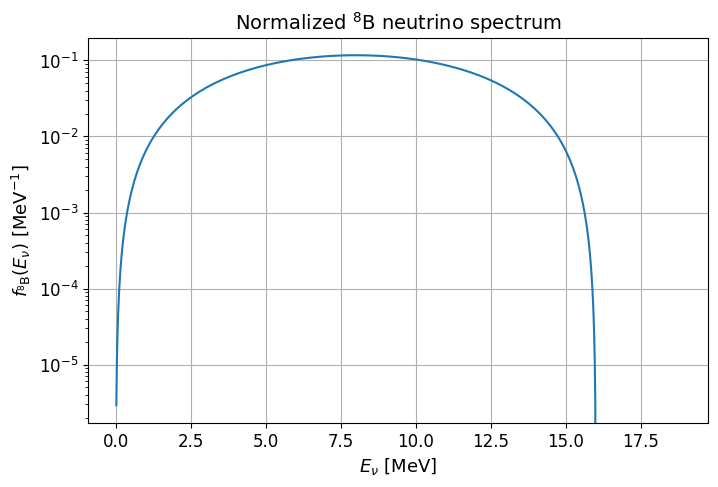

In [62]:
fig, ax = plt.subplots()

ax.plot(b8["E_MeV"], b8["spectrum_per_MeV"])
ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [MeV]")
ax.set_ylabel(r"$f_{^8\mathrm{B}}(E_\nu)$ [MeV$^{-1}$]")
ax.set_title(r"Normalized $^8\mathrm{B}$ neutrino spectrum")

plt.show()

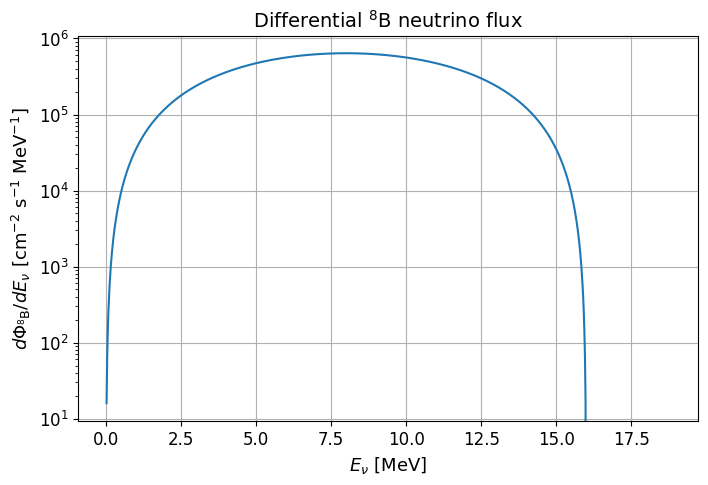

In [63]:
b8 = b8.assign(dphi_dE=phi_b8 * b8["spectrum_per_MeV"])

fig, ax = plt.subplots()

ax.plot(b8["E_MeV"], b8["dphi_dE"])
ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [MeV]")
ax.set_ylabel(r"$d\Phi_{^8\mathrm{B}}/dE_\nu$ [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
ax.set_title(r"Differential $^8\mathrm{B}$ neutrino flux")

plt.show()

## 4. Detector exposure and number of target electrons

For water,

$$
N_e = 10N_A\frac{M_{\rm water}}{18~\mathrm{g}}.
$$

The factor 10 appears because one molecule of water, $H_2O$, has 10 electrons.

We use the example exposure:

$$
M_{\rm water}=100~\mathrm{kton},
\qquad
T_{\rm live}=1~\mathrm{year}.
$$


In [64]:
N_A = 6.02214076e23
seconds_per_year = 365.25 * 24 * 3600

mass_g = 100.0e9          # 100 kton water = 100e9 g
T_live = seconds_per_year # one year in seconds

N_e = 10.0 * N_A * mass_g / 18.0

print(f"N_e = {N_e:.6e}")
print(f"T_live = {T_live:.6e} s")

N_e = 3.345634e+34
T_live = 3.155760e+07 s


## 5. Build the event template $m_j$

For recoil-energy bin $j$,

$$
\mu_j(\alpha_B)
=
\alpha_B N_eT_{\rm live}
\int_{T_j}^{T_{j+1}}dT_e
\int dE_\nu\,
\Phi_{^8\mathrm{B}}f_{^8\mathrm{B}}(E_\nu)
\frac{d\sigma_{\nu_e e}(E_\nu,T_e)}{dT_e}.
$$

In Masterclass 1, oscillations are not included, so

$$
\mu_j(\alpha_B)=\alpha_B m_j.
$$

The fixed template $m_j$ is the prediction for $\alpha_B=1$.


In [65]:
def build_event_template(Tmin=4.5, Tmax=14.0, bin_width=0.5):
    """
    Build the expected recoil spectrum m_j for alpha_B = 1.
    """
    xs_local = xs.copy()

    # Interpolate the normalized B8 spectral shape to the cross-section E grid.
    shape = np.interp(
        xs_local["E_MeV"],
        b8["E_MeV"],
        b8["spectrum_per_MeV"],
        left=0.0,
        right=0.0,
    )

    xs_local = xs_local.assign(dphi_dE=phi_b8 * shape)

    E_grid = np.sort(xs_local["E_MeV"].unique())
    T_grid = np.sort(xs_local["T_e_MeV"].unique())

    dE = np.median(np.diff(E_grid))
    dT = np.median(np.diff(T_grid))

    edges = np.arange(Tmin, Tmax + 0.5 * bin_width, bin_width)
    nbins = len(edges) - 1

    bin_id = np.digitize(xs_local["T_e_MeV"], edges) - 1
    valid = (0 <= bin_id) & (bin_id < nbins)

    integrand = (
        N_e * T_live
        * xs_local["dphi_dE"]
        * xs_local["dsigma_nue_cm2_per_MeV"]
        * dE * dT
    )

    m = np.bincount(
        bin_id[valid],
        weights=integrand[valid],
        minlength=nbins,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    return {
        "edges": edges,
        "centers": centers,
        "m": m,
        "dE": dE,
        "dT": dT,
        "E_grid": E_grid,
        "T_grid": T_grid,
        "Tmin": Tmin,
        "Tmax": Tmax,
        "bin_width": bin_width,
    }


template = build_event_template(Tmin=4.5, Tmax=14.0, bin_width=0.5)

edges = template["edges"]
centers = template["centers"]
m = template["m"]

print(f"cross-section grid = {len(template['E_grid'])} x {len(template['T_grid'])}")
print(f"dE = {template['dE']:.6f} MeV")
print(f"dT = {template['dT']:.6f} MeV")
print(f"number of bins = {len(m)}")
print(f"total expected events = {m.sum():.3f}")

cross-section grid = 188 x 181
dE = 0.100267 MeV
dT = 0.100000 MeV
number of bins = 19
total expected events = 186693.543


## 6. Recoil-electron spectrum

Now we plot the SK-like recoil spectrum $m_j$, i.e. expected events per recoil-energy bin.


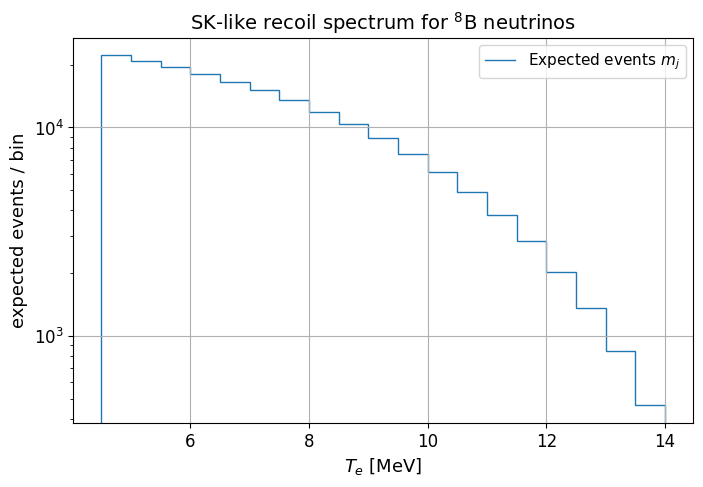

In [66]:
fig, ax = plt.subplots()

ax.stairs(m, edges, label=r"Expected events $m_j$")
ax.set_yscale("log")
ax.set_xlabel(r"$T_e$ [MeV]")
ax.set_ylabel("expected events / bin")
ax.set_title(r"SK-like recoil spectrum for $^8\mathrm{B}$ neutrinos")
ax.legend()

plt.show()

In [67]:
event_table = pd.DataFrame({
    "T_low_MeV": edges[:-1],
    "T_high_MeV": edges[1:],
    "T_center_MeV": centers,
    "expected_events": m,
})

display(event_table.head())
print(f"Total expected events above {template['Tmin']:.1f} MeV = {m.sum():.3f}")

,T_low_MeV,T_high_MeV,T_center_MeV,expected_events
0,4.5,5.0,4.75,22174.578056
1,5.0,5.5,5.25,20898.293926
2,5.5,6.0,5.75,19528.653010
3,6.0,6.5,6.25,18080.902403
4,6.5,7.0,6.75,16572.947595


Total expected events above 4.5 MeV = 186693.543


## 7. Generate pseudo-data

We choose a true normalization

$$
\alpha_B^{\rm true}=1
$$

and generate Poisson-distributed counts:

$$
n_j\sim\mathrm{Poisson}(\alpha_B^{\rm true}m_j).
$$


In [68]:
rng = np.random.default_rng(12345)

alpha_true = 1.0
n = rng.poisson(alpha_true * m)

print(f"sum expected = {m.sum():.3f}")
print(f"sum pseudo-data = {n.sum()}")

sum expected = 186693.543
sum pseudo-data = 186665


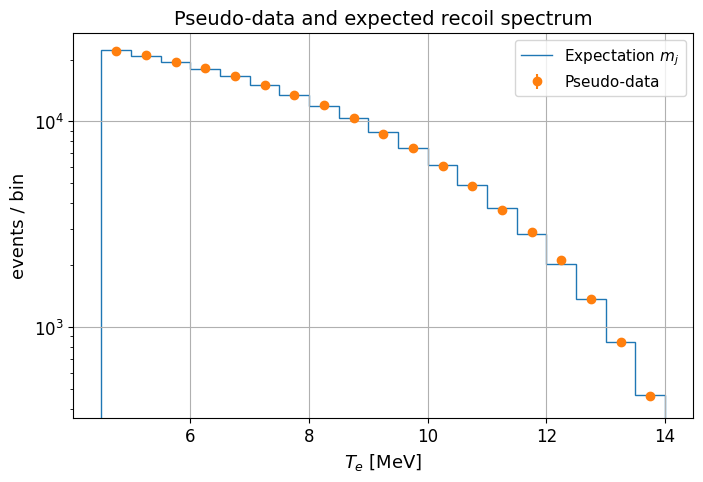

In [69]:
fig, ax = plt.subplots()

ax.stairs(m, edges, label=r"Expectation $m_j$")
ax.errorbar(
    centers,
    n,
    yerr=np.sqrt(np.maximum(n, 1)),
    fmt="o",
    label="Pseudo-data",
)

ax.set_yscale("log")
ax.set_xlabel(r"$T_e$ [MeV]")
ax.set_ylabel("events / bin")
ax.set_title("Pseudo-data and expected recoil spectrum")
ax.legend()

plt.show()

## 8. One-parameter fit of $\alpha_B$

The model is

$$
\mu_j(\alpha_B)=\alpha_Bm_j.
$$

For Poisson bins,

$$
\ell(\alpha_B)
=
\sum_j
\left[
n_j\ln\mu_j(\alpha_B)-\mu_j(\alpha_B)
\right]
+\mathrm{const}.
$$

We define

$$
q(\alpha_B)
=
-2\left[
\ell(\alpha_B)-\ell(\hat\alpha_B)
\right].
$$

For one fitted parameter, the usual approximate $1\sigma$ interval is

$$
q(\alpha_B)\le1.
$$


In [70]:
alphas = np.linspace(0.98, 1.02, 401)

mu = alphas[:, None] * m[None, :]
mu = np.maximum(mu, 1e-300)

ll = np.sum(n[None, :] * np.log(mu) - mu, axis=1)
q = -2.0 * (ll - ll.max())

alpha_hat = alphas[np.argmax(ll)]

inside = alphas[q <= 1.0]
alpha_left = inside[0]
alpha_right = inside[-1]

print(f"alpha_hat = {alpha_hat:.6f}")
print(f"q <= 1 interval: {alpha_left:.6f} ... {alpha_right:.6f}")

alpha_hat = 0.999800
q <= 1 interval: 0.997600 ... 1.002100


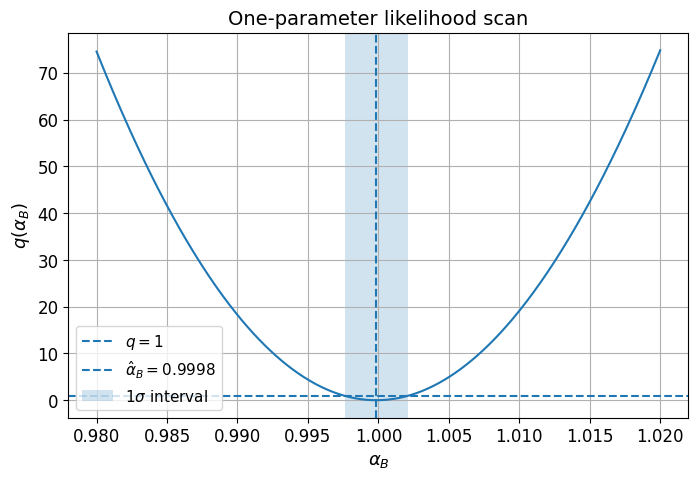

In [71]:
fig, ax = plt.subplots()

ax.plot(alphas, q)
ax.axhline(1.0, linestyle="--", label=r"$q=1$")
ax.axvline(alpha_hat, linestyle="--", label=fr"$\hat\alpha_B={alpha_hat:.4f}$")
ax.axvspan(alpha_left, alpha_right, alpha=0.2, label=r"$1\sigma$ interval")

ax.set_xlabel(r"$\alpha_B$")
ax.set_ylabel(r"$q(\alpha_B)$")
ax.set_title(r"One-parameter likelihood scan")
ax.legend()

plt.show()

## 9. Analytic check

Because the model is linear,

$$
\mu_j(\alpha_B)=\alpha_B m_j,
$$

the maximum-likelihood estimator is

$$
\hat\alpha_B
=
\frac{\sum_j n_j}{\sum_j m_j}.
$$

This is a useful check of the grid fit.


In [72]:
alpha_hat_check = n.sum() / m.sum()

print(f"grid alpha_hat     = {alpha_hat:.6f}")
print(f"analytic alpha_hat = {alpha_hat_check:.6f}")
print(f"difference         = {alpha_hat - alpha_hat_check:.6e}")

grid alpha_hat     = 0.999800
analytic alpha_hat = 0.999847
difference         = -4.711447e-05


## 10. Final summary

This notebook produced:

- normalized ${}^8\mathrm{B}$ spectrum;
- differential ${}^8\mathrm{B}$ flux;
- SK-like recoil-electron event template $m_j$;
- total expected events above a chosen threshold;
- pseudo-data $n_j$ in the same bins;
- best-fit $\hat\alpha_B$;
- one-dimensional interval from $q(\alpha_B)$;
- analytic check of the fitted normalization.


## 11. Threshold sensitivity

Now we repeat the same one-parameter fit for several recoil-energy thresholds:

$$
T_{\min}=3,\ 4.5,\ 6\ \mathrm{MeV}.
$$

For each threshold we do the same chain:

$$
T_{\min}
\rightarrow
m_j=\mu_j(\alpha_B=1)
\rightarrow
n_j
\rightarrow
\hat{\alpha}_B
\rightarrow
q(\alpha_B)
\rightarrow
1\sigma\ \mathrm{interval}.
$$

The threshold means that we only keep recoil-electron events with

$$
T_e>T_{\min}.
$$

If the threshold is higher, fewer events survive. Therefore the statistical uncertainty becomes larger. Roughly,

$$
\sigma_{\alpha_B}\sim\frac{1}{\sqrt{\sum_j m_j}}.
$$

We also check whether the result is stable against binning changes. For that, we keep

$$
T_{\min}=4.5\ \mathrm{MeV}
$$

and repeat the fit for different bin widths:

$$
\Delta T=0.25,\ 0.5,\ 1.0\ \mathrm{MeV}.
$$


In [73]:
def fit_alpha_B(m, alpha_true=1.0, seed=12345, alpha_min=0.98, alpha_max=1.02, n_alpha=2001):
    """
    Fit the flux normalization alpha_B for the linear model

        mu_j(alpha_B) = alpha_B * m_j.

    Here m_j is the expected event template for alpha_B = 1.
    The pseudo-data n_j are generated from a Poisson distribution.
    """

    rng = np.random.default_rng(seed)

    # Pseudo-data in the same bins:
    #
    #     n_j ~ Poisson(alpha_true * m_j)
    #
    n = rng.poisson(alpha_true * m)

    # Grid of alpha_B values
    alphas = np.linspace(alpha_min, alpha_max, n_alpha)

    # Expected event counts for every alpha_B:
    #
    #     mu_j(alpha_B) = alpha_B * m_j
    #
    mu = alphas[:, None] * m[None, :]
    mu = np.maximum(mu, 1e-300)

    # Poisson log-likelihood up to an irrelevant constant:
    #
    #     ell(alpha_B) = sum_j [n_j log(mu_j) - mu_j]
    #
    ll = np.sum(n[None, :] * np.log(mu) - mu, axis=1)

    # For this linear one-parameter model the best-fit value is also known analytically:
    #
    #     alpha_hat = sum_j n_j / sum_j m_j
    #
    alpha_hat = n.sum() / m.sum()

    # Compute the likelihood at the analytic best fit.
    # This avoids small grid-spacing errors in q(alpha_B).
    mu_hat = np.maximum(alpha_hat * m, 1e-300)
    ll_hat = np.sum(n * np.log(mu_hat) - mu_hat)

    # Likelihood-ratio statistic:
    #
    #     q(alpha_B) = -2 [ell(alpha_B) - ell(alpha_hat)]
    #
    q = -2.0 * (ll - ll_hat)

    # Approximate 1 sigma interval for one parameter:
    #
    #     q(alpha_B) <= 1
    #
    inside = alphas[q <= 1.0]

    if len(inside) == 0:
        alpha_low = np.nan
        alpha_high = np.nan
    else:
        alpha_low = inside[0]
        alpha_high = inside[-1]

    return {
        "m": m,
        "n": n,
        "alphas": alphas,
        "q": q,
        "alpha_hat": alpha_hat,
        "alpha_low": alpha_low,
        "alpha_high": alpha_high,
        "total_expected": m.sum(),
        "total_observed": n.sum(),
        "stat_scale": 1.0 / np.sqrt(m.sum()),
    }

In [74]:
# Thresholds to compare
thresholds = [3.0, 4.5, 6.0]

threshold_results = {}
threshold_rows = []

for Tmin in thresholds:
    # Build the expected template m_j = mu_j(alpha_B = 1)
    # for the chosen threshold.
    template_thr = build_event_template(
        Tmin=Tmin,
        Tmax=14.0,
        bin_width=0.5,
    )

    m_thr = template_thr["m"]

    # Repeat the alpha_B fit.
    fit_thr = fit_alpha_B(
        m=m_thr,
        alpha_true=1.0,
        seed=12345,
    )

    threshold_results[Tmin] = {
        "template": template_thr,
        "fit": fit_thr,
    }

    threshold_rows.append({
        "Tmin_MeV": Tmin,
        "number_of_bins": len(m_thr),
        "sum_mj_expected": fit_thr["total_expected"],
        "sum_nj_pseudodata": fit_thr["total_observed"],
        "alpha_hat": fit_thr["alpha_hat"],
        "alpha_low_1sigma": fit_thr["alpha_low"],
        "alpha_high_1sigma": fit_thr["alpha_high"],
        "minus_error": fit_thr["alpha_hat"] - fit_thr["alpha_low"],
        "plus_error": fit_thr["alpha_high"] - fit_thr["alpha_hat"],
        "stat_scale_1_sqrt_N": fit_thr["stat_scale"],
    })

threshold_summary = pd.DataFrame(threshold_rows)

display(threshold_summary)

,Tmin_MeV,number_of_bins,sum_mj_expected,sum_nj_pseudodata,alpha_hat,alpha_low_1sigma,alpha_high_1sigma,minus_error,plus_error,stat_scale_1_sqrt_N
0,3.0,22,259784.968745,259796,1.000042,0.99810,1.00200,0.001942,0.001958,0.001962
1,4.5,19,186693.542740,186665,0.999847,0.99754,1.00216,0.002307,0.002313,0.002314
2,6.0,16,124092.017748,124075,0.999863,0.99704,1.00270,0.002823,0.002837,0.002839


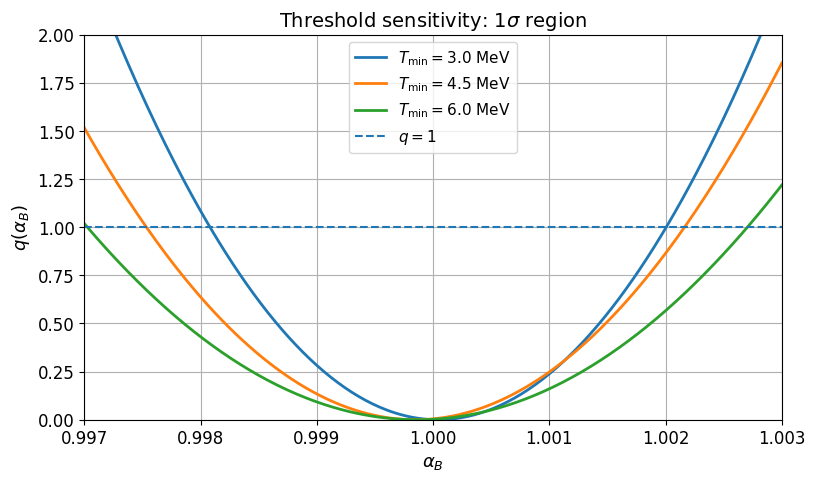

In [75]:
fig, ax = plt.subplots(figsize=(9, 5))

for Tmin in thresholds:
    fit_thr = threshold_results[Tmin]["fit"]

    ax.plot(
        fit_thr["alphas"],
        fit_thr["q"],
        linewidth=2,
        label=fr"$T_{{\min}}={Tmin}$ MeV",
    )

ax.axhline(1.0, linestyle="--", linewidth=1.5, label=r"$q=1$")

ax.set_xlim(0.997, 1.003)
ax.set_ylim(0, 2)

ax.set_xlabel(r"$\alpha_B$")
ax.set_ylabel(r"$q(\alpha_B)$")
ax.set_title(r"Threshold sensitivity: 1$\sigma$ region")
ax.legend()
ax.grid(True)

plt.show()

In [76]:
for _, row in threshold_summary.iterrows():
    print(f"Tmin = {row['Tmin_MeV']:.1f} MeV")
    print(f"  total expected events sum_j m_j = {row['sum_mj_expected']:.3f}")
    print(f"  pseudo-data total sum_j n_j     = {row['sum_nj_pseudodata']:.0f}")
    print(f"  alpha_hat                      = {row['alpha_hat']:.6f}")
    print(
        f"  1 sigma interval               = "
        f"[{row['alpha_low_1sigma']:.6f}, {row['alpha_high_1sigma']:.6f}]"
    )
    print(f"  statistical scale 1/sqrt(N)    = {row['stat_scale_1_sqrt_N']:.6f}")
    print()

print("Interpretation:")
print("When T_min increases, fewer recoil-electron events remain.")
print("Therefore sum_j m_j decreases and the alpha_B interval becomes wider.")
print("This is the threshold sensitivity: the fit becomes less precise when the threshold is higher.")

Tmin = 3.0 MeV
  total expected events sum_j m_j = 259784.969
  pseudo-data total sum_j n_j     = 259796
  alpha_hat                      = 1.000042
  1 sigma interval               = [0.998100, 1.002000]
  statistical scale 1/sqrt(N)    = 0.001962

Tmin = 4.5 MeV
  total expected events sum_j m_j = 186693.543
  pseudo-data total sum_j n_j     = 186665
  alpha_hat                      = 0.999847
  1 sigma interval               = [0.997540, 1.002160]
  statistical scale 1/sqrt(N)    = 0.002314

Tmin = 6.0 MeV
  total expected events sum_j m_j = 124092.018
  pseudo-data total sum_j n_j     = 124075
  alpha_hat                      = 0.999863
  1 sigma interval               = [0.997040, 1.002700]
  statistical scale 1/sqrt(N)    = 0.002839

Interpretation:
When T_min increases, fewer recoil-electron events remain.
Therefore sum_j m_j decreases and the alpha_B interval becomes wider.
This is the threshold sensitivity: the fit becomes less precise when the threshold is higher.


### Stability against binning changes

Now we fix the threshold

$$
T_{\min}=4.5\ \mathrm{MeV}
$$

and change only the bin width:

$$
\Delta T=0.25,\ 0.5,\ 1.0\ \mathrm{MeV}.
$$

The fitted value $\hat\alpha_B$ should not change strongly under reasonable binning changes. Small changes are expected because the pseudo-data are Poisson-fluctuated.


In [77]:
bin_widths = [0.25, 0.5, 1.0]
Tmin_fixed = 4.5

binning_results = {}
binning_rows = []

for bin_width in bin_widths:
    # Build the event template for this binning.
    template_bin = build_event_template(
        Tmin=Tmin_fixed,
        Tmax=14.0,
        bin_width=bin_width,
    )

    m_bin = template_bin["m"]

    # Fit alpha_B for the same threshold but different bin width.
    fit_bin = fit_alpha_B(
        m=m_bin,
        alpha_true=1.0,
        seed=12345,
    )

    binning_results[bin_width] = {
        "template": template_bin,
        "fit": fit_bin,
    }

    binning_rows.append({
        "Tmin_MeV": Tmin_fixed,
        "bin_width_MeV": bin_width,
        "number_of_bins": len(m_bin),
        "sum_mj_expected": fit_bin["total_expected"],
        "sum_nj_pseudodata": fit_bin["total_observed"],
        "alpha_hat": fit_bin["alpha_hat"],
        "alpha_low_1sigma": fit_bin["alpha_low"],
        "alpha_high_1sigma": fit_bin["alpha_high"],
        "minus_error": fit_bin["alpha_hat"] - fit_bin["alpha_low"],
        "plus_error": fit_bin["alpha_high"] - fit_bin["alpha_hat"],
        "stat_scale_1_sqrt_N": fit_bin["stat_scale"],
    })

binning_summary = pd.DataFrame(binning_rows)

display(binning_summary)

,Tmin_MeV,bin_width_MeV,number_of_bins,sum_mj_expected,sum_nj_pseudodata,alpha_hat,alpha_low_1sigma,alpha_high_1sigma,minus_error,plus_error,stat_scale_1_sqrt_N
0,4.5,0.25,38,186693.542740,186544,0.999199,0.99690,1.00150,0.002299,0.002301,0.002314
1,4.5,0.50,19,186693.542740,186665,0.999847,0.99754,1.00216,0.002307,0.002313,0.002314
2,4.5,1.00,9,186228.517699,186409,1.000969,0.99866,1.00328,0.002309,0.002311,0.002317


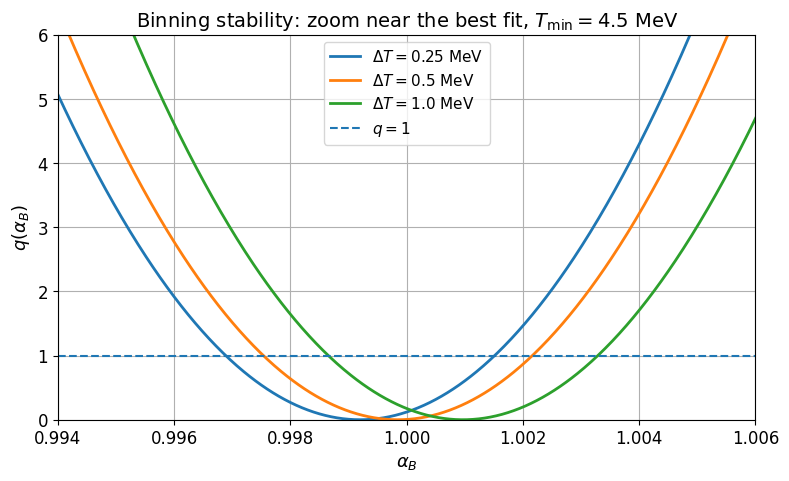

In [78]:
# ============================================================
# More visible q(alpha_B) plot for different bin widths
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

for bin_width in bin_widths:
    fit_bin = binning_results[bin_width]["fit"]

    ax.plot(
        fit_bin["alphas"],
        fit_bin["q"],
        linewidth=2,
        label=fr"$\Delta T={bin_width}$ MeV",
    )

ax.axhline(1.0, linestyle="--", linewidth=1.5, label=r"$q=1$")

ax.set_xlim(0.994, 1.006)
ax.set_ylim(0, 6)

ax.set_xlabel(r"$\alpha_B$")
ax.set_ylabel(r"$q(\alpha_B)$")
ax.set_title(
    fr"Binning stability: zoom near the best fit, $T_{{\min}}={Tmin_fixed}$ MeV"
)
ax.legend()
ax.grid(True)

plt.show()

In [79]:
overlap_low = binning_summary["alpha_low_1sigma"].max()
overlap_high = binning_summary["alpha_high_1sigma"].min()

print(f"Common overlap of the 1 sigma intervals:")
print(f"  [{overlap_low:.6f}, {overlap_high:.6f}]")
print()

if overlap_low <= overlap_high:
    print("Result: stable against these binning changes.")
    print("The 1 sigma intervals overlap.")
else:
    print("Result: possible binning sensitivity.")
    print("The 1 sigma intervals do not overlap.")

print()
print("Interpretation:")
print("Changing the bin width changes how events are grouped into recoil-energy bins.")
print("However, the fitted flux normalization alpha_B should remain compatible within errors.")
print("If the intervals overlap, the result is not an artifact of one particular binning choice.")

Common overlap of the 1 sigma intervals:
  [0.998660, 1.001500]

Result: stable against these binning changes.
The 1 sigma intervals overlap.

Interpretation:
Changing the bin width changes how events are grouped into recoil-energy bins.
However, the fitted flux normalization alpha_B should remain compatible within errors.
If the intervals overlap, the result is not an artifact of one particular binning choice.


### Summary of threshold sensitivity

The threshold study shows how the quality of the flux-normalization fit depends on the recoil-energy cut.

A higher threshold keeps fewer events:

$$
T_{\min}\uparrow
\quad\Rightarrow\quad
\sum_j m_j\downarrow.
$$

Since the statistical scale behaves approximately as

$$
\sigma_{\alpha_B}\sim\frac{1}{\sqrt{\sum_j m_j}},
$$

the uncertainty on $\alpha_B$ increases when the threshold is raised.

The binning test checks that the extracted normalization is not an artifact of a particular choice of recoil-energy bin width.


## Outputs for the project Part I

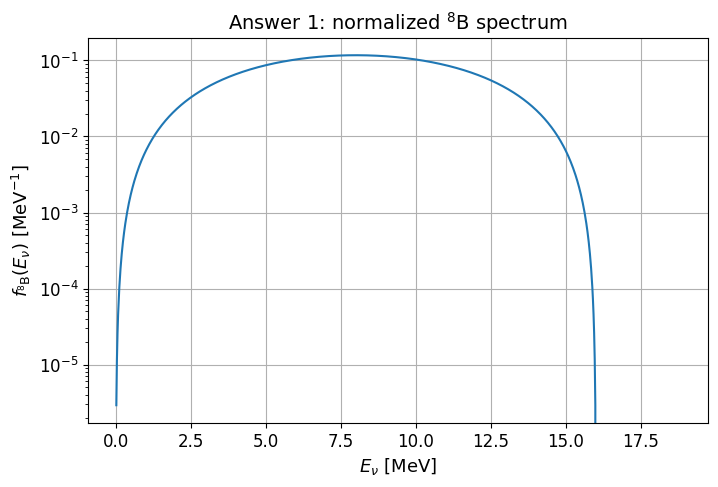

Answer 1:
Integral of f_B8(E_nu) = 1.000000000000
Phi_B8 = 5.460000e+06 cm^-2 s^-1


In [81]:
# === ANSWER 1: normalized 8B spectrum f_B8(E_nu) ===

fig, ax = plt.subplots()

ax.plot(b8["E_MeV"], b8["spectrum_per_MeV"])
ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [MeV]")
ax.set_ylabel(r"$f_{^8\mathrm{B}}(E_\nu)$ [MeV$^{-1}$]")
ax.set_title(r"Answer 1: normalized $^8\mathrm{B}$ spectrum")

plt.show()

print(r"Answer 1:")
print(f"Integral of f_B8(E_nu) = {norm_b8:.12f}")
print(f"Phi_B8 = {phi_b8:.6e} cm^-2 s^-1")

,$T_j$ low [MeV],$T_{j+1}$ high [MeV],$T_e$ center [MeV],$m_j$ expected events
0,4.5,5.0,4.75,22174.578056
1,5.0,5.5,5.25,20898.293926
2,5.5,6.0,5.75,19528.653010
3,6.0,6.5,6.25,18080.902403
4,6.5,7.0,6.75,16572.947595
5,7.0,7.5,7.25,15024.765498
6,7.5,8.0,7.75,13457.817477
7,8.0,8.5,8.25,11894.462381
8,8.5,9.0,8.75,10357.369574
9,9.0,9.5,9.25,8868.931963


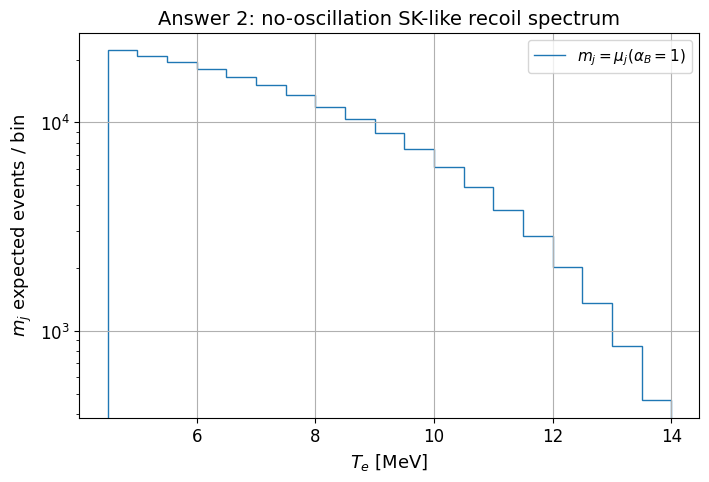

In [82]:
# === ANSWER 2: no-oscillation SK-like recoil spectrum ===

answer2_table = pd.DataFrame({
    r"$T_j$ low [MeV]": edges[:-1],
    r"$T_{j+1}$ high [MeV]": edges[1:],
    r"$T_e$ center [MeV]": centers,
    r"$m_j$ expected events": m,
})

display(answer2_table)

fig, ax = plt.subplots()

ax.stairs(m, edges, label=r"$m_j=\mu_j(\alpha_B=1)$")
ax.set_yscale("log")
ax.set_xlabel(r"$T_e$ [MeV]")
ax.set_ylabel(r"$m_j$ expected events / bin")
ax.set_title(r"Answer 2: no-oscillation SK-like recoil spectrum")
ax.legend()

plt.show()

In [83]:
# === ANSWER 3: exposure and target electrons ===

answer3_table = pd.DataFrame({
    "quantity": [
        r"$M_{\rm water}$",
        r"$T_{\rm live}$",
        r"exposure",
        r"$N_e$",
        r"$N_eT_{\rm live}$",
    ],
    "value": [
        f"{mass_g / 1e9:.1f} kton",
        f"{T_live:.6e} s",
        f"{mass_g / 1e9:.1f} kton year",
        f"{N_e:.6e}",
        f"{N_e * T_live:.6e} electron s",
    ],
})

display(answer3_table)

,quantity,value
0,$M_{\rm water}$,100.0 kton
1,$T_{\rm live}$,3.155760e+07 s
2,exposure,100.0 kton year
3,$N_e$,3.345634e+34
4,$N_eT_{\rm live}$,1.055802e+42 electron s


In [84]:
# === ANSWER 4: total number of events above the chosen threshold ===

answer4_table = pd.DataFrame({
    r"$T_{\min}$ [MeV]": [template["Tmin"]],
    r"$T_{\max}$ [MeV]": [template["Tmax"]],
    r"$\Delta T$ [MeV]": [template["bin_width"]],
    "number of bins": [len(m)],
    r"$\sum_j m_j$ expected events": [m.sum()],
})

display(answer4_table)

print(r"Answer 4:")
print(
    fr"Total expected events above T_min = {template['Tmin']:.1f} MeV:"
    f" {m.sum():.3f}"
)

,$T_{\min}$ [MeV],$T_{\max}$ [MeV],$\Delta T$ [MeV],number of bins,$\sum_j m_j$ expected events
0,4.5,14.0,0.5,19,186693.54274


Answer 4:
Total expected events above T_min = 4.5 MeV: 186693.543


,$T_{\min}$ [MeV],$T_{\max}$ [MeV],$\Delta T$ [MeV],number of bins,$\sum_j m_j$ expected events,$1/\sqrt{\sum_j m_j}$
0,3.0,14.0,0.5,22,259784.968745,0.001962
1,4.5,14.0,0.5,19,186693.542740,0.002314
2,6.0,14.0,0.5,16,124092.017748,0.002839


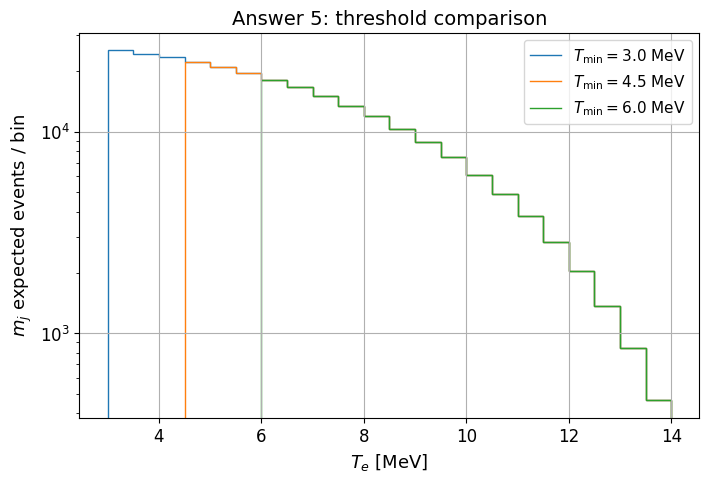

In [85]:
# === ANSWER 5: repeat for several thresholds ===

answer5_thresholds = [3.0, 4.5, 6.0]

answer5_rows = []

fig, ax = plt.subplots()

for Tmin in answer5_thresholds:
    template_thr = build_event_template(
        Tmin=Tmin,
        Tmax=14.0,
        bin_width=0.5,
    )

    m_thr = template_thr["m"]
    edges_thr = template_thr["edges"]

    answer5_rows.append({
        r"$T_{\min}$ [MeV]": Tmin,
        r"$T_{\max}$ [MeV]": template_thr["Tmax"],
        r"$\Delta T$ [MeV]": template_thr["bin_width"],
        "number of bins": len(m_thr),
        r"$\sum_j m_j$ expected events": m_thr.sum(),
        r"$1/\sqrt{\sum_j m_j}$": 1.0 / np.sqrt(m_thr.sum()),
    })

    ax.stairs(
        m_thr,
        edges_thr,
        label=fr"$T_{{\min}}={Tmin}$ MeV",
    )

answer5_table = pd.DataFrame(answer5_rows)

display(answer5_table)

ax.set_yscale("log")
ax.set_xlabel(r"$T_e$ [MeV]")
ax.set_ylabel(r"$m_j$ expected events / bin")
ax.set_title(r"Answer 5: threshold comparison")
ax.legend()

plt.show()